# Exploratory Data Analysis (EDA)

## Objective
The goal of this notebook is to explore the dataset, understand distributions, detect patterns, and identify initial signals of customer churn behavior before performing deeper feature-level analysis.

In [1]:
# Load cleaned dataset for analysis
import pandas as pd

df = pd.read_csv("E:/Customer Churn Analysis/data/processed/telco_churn_cleaned.csv")

df.head()

c:\Users\mahdi\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\mahdi\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_flag,tenure_group,total_revenue
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-1 year,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,2-4 years,1936.30
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-1 year,107.70
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,2-4 years,1903.50
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-1 year,141.40


In [2]:
# Overall churn rate
df["churn_flag"].value_counts(normalize=True) * 100

churn_flag
0    73.463013
1    26.536987
Name: proportion, dtype: float64

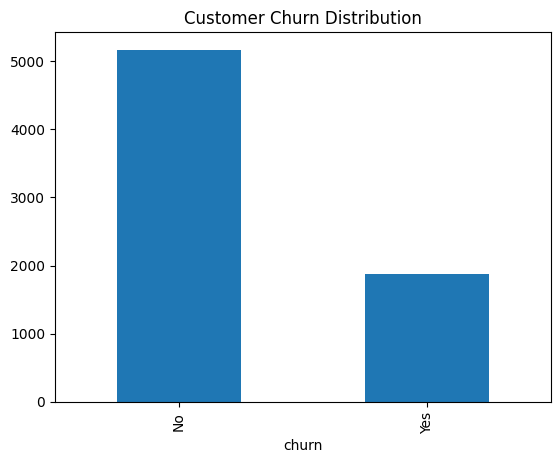

In [3]:
import matplotlib.pyplot as plt

df["churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.show()

In [4]:
# Gender distribution
df["gender"].value_counts(normalize=True) * 100

gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

In [5]:
# Senior citizen churn behavior
df.groupby("seniorcitizen")["churn_flag"].mean()

seniorcitizen
0    0.236062
1    0.416813
Name: churn_flag, dtype: float64

In [7]:
df.groupby("contract")["churn_flag"].mean().sort_values(ascending=False)*100

contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: churn_flag, dtype: float64

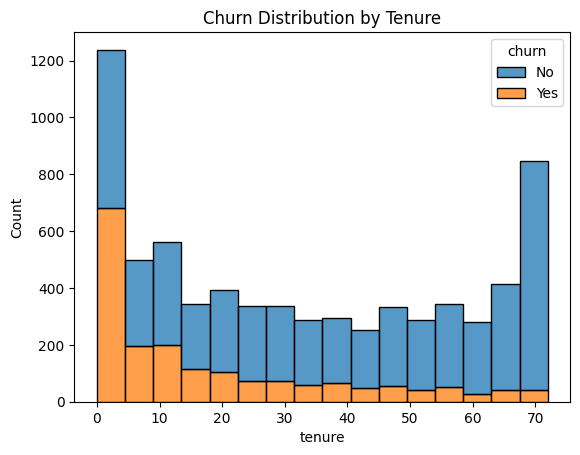

In [8]:
import seaborn as sns

sns.histplot(data=df, x="tenure", hue="churn", multiple="stack")
plt.title("Churn Distribution by Tenure")
plt.show()

Customer churn is highly front-loaded.
Most customers who leave do so within the first 12 months.
Retention improves significantly after the initial engagement period.

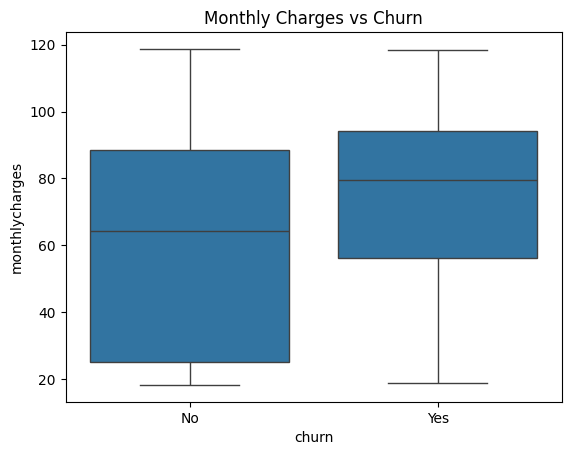

In [11]:
sns.boxplot(x="churn", y="monthlycharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Customers with higher monthly charges tend to churn more frequently, suggesting that pricing pressure or perceived lack of value may be a key driver of customer attrition.

## Key Observations

- Overall churn rate is ~26%
- Month-to-month contracts show significantly higher churn
- New customers (low tenure) are more likely to churn
- Higher monthly charges are associated with churn risk